In [22]:
import torch
import torch.nn as nn
import pandas as pd
import torchvision
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader,random_split
from torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt
import torchvision.models as models
from torch.optim.lr_scheduler import ReduceLROnPlateau
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
class_to_idx = {cls: idx for idx, cls in enumerate(CLASS_NAMES)}

In [3]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

In [4]:
class DatasetLoad(Dataset):

    def __init__(self,csv_file,image_file,transform = None):
        self.data =  pd.read_csv(csv_file)
        self.image = image_file
        self.transform =  transform

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self,idx):
        img_name = self.data.iloc[idx]["image_id"] + ".jpg"
        img_path = os.path.join(self.image, img_name)
        image = Image.open(img_path).convert("RGB")

        label_str =  self.data.iloc[idx]["dx"]
        label =  class_to_idx[label_str]

        if self.transform:
            image = self.transform(image)
        return image,torch.tensor(label,dtype = torch.long)


In [5]:
full_dataset  = DatasetLoad(
        csv_file ='D:\Skin cancer Using pytorch\HAM10000_metadata.csv',
        image_file ='D:\Skin cancer Using pytorch\HAM10000_images',
        transform  =  transform
)

In [6]:
train_size = int(0.8 * len(full_dataset))
# int(0.8 * 10015) = int(8012.0) = 8012
test_size = len(full_dataset) - train_size
# 10015 - 8012 = 2003

In [7]:
train_data, test_data = random_split(full_dataset, [train_size, test_size])

train_dataloader = DataLoader(train_data, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=16, shuffle=False)

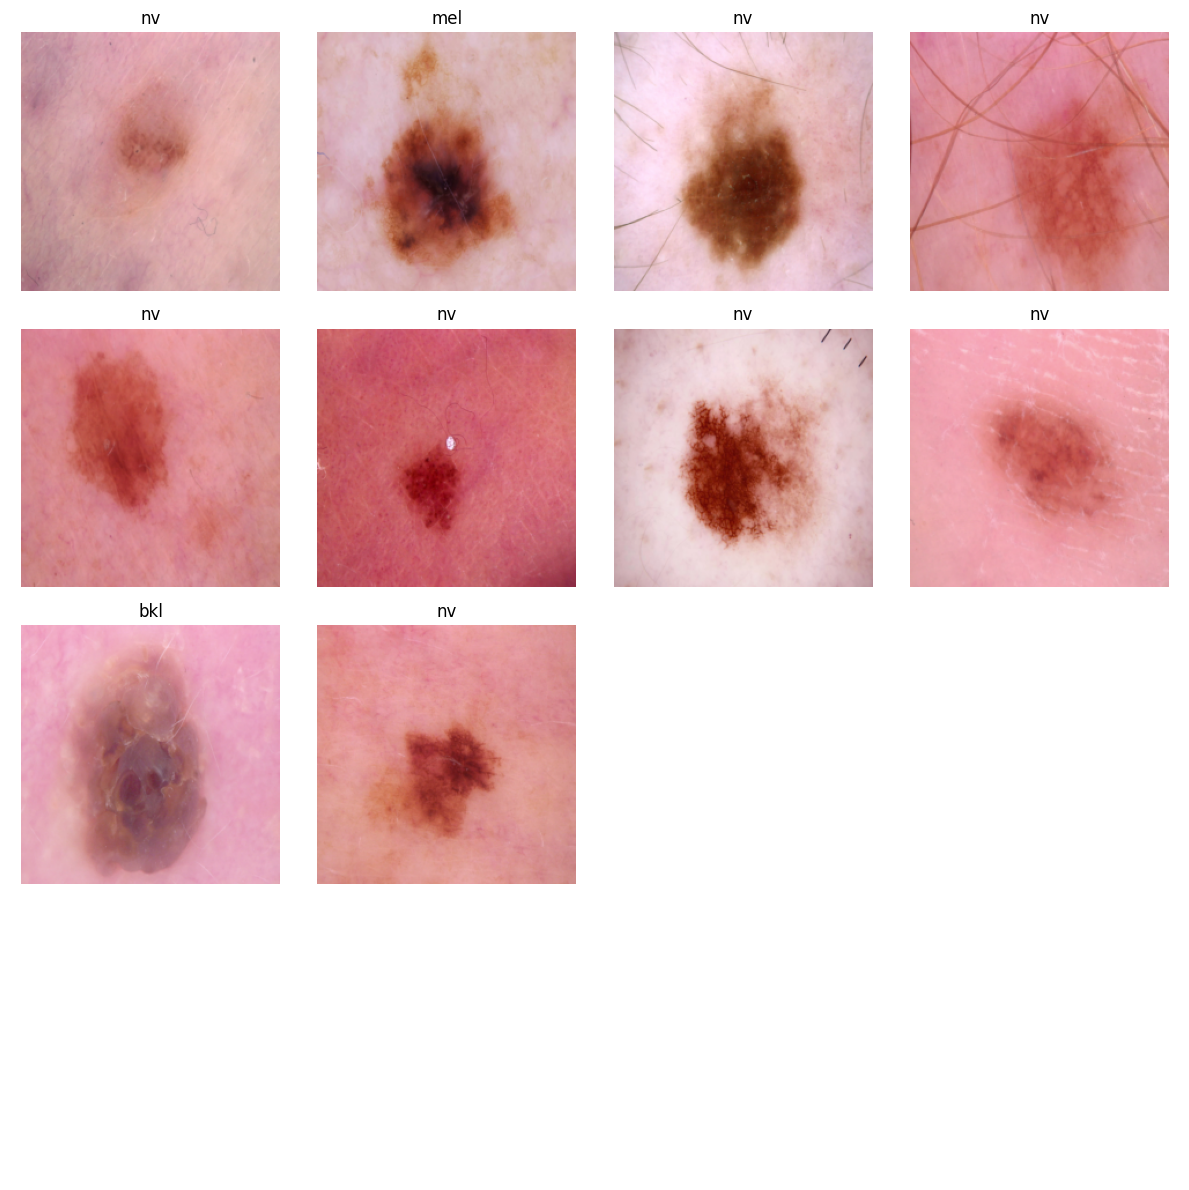

In [8]:
# Get 10 random samples from train_data
indices = torch.randperm(len(train_data))[:10]
random_samples = [train_data[i] for i in indices]

# Create a 4x4 grid (we'll use first 10 images, leaving 6 empty)
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

# Plot the images
for idx, (image, label) in enumerate(random_samples):
    # Denormalize the image for display
    image = image.permute(1, 2, 0)
    image = image * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
    image = torch.clamp(image, 0, 1)
    
    axes[idx].imshow(image)
    axes[idx].set_title(CLASS_NAMES[label])
    axes[idx].axis('off')

# Hide remaining subplots
for idx in range(len(random_samples), 16):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

Custom CNN model


In [8]:
class cnnModel(nn.Module):
    def __init__(self,num_classes=7):
        super ().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,32,kernel_size =3 , padding = 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32,64,kernel_size =3 , padding = 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64,128,kernel_size =3 , padding = 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )
        self.classification = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*28*28,512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512,num_classes)
        )
    def forward(self,x):
        x = self.features(x)
        x = self.classification(x)
        return x



In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
        

Using device: cuda


In [10]:
model = cnnModel(num_classes=7).to(device)

In [11]:
print(next(model.parameters()).device)  # must say cuda:0 before training

cuda:0


In [12]:
optimizer  = optim.Adam(model.parameters(),lr = 0.001)
criterion = nn.CrossEntropyLoss()
for epoch in range(7):
    model.train()
    total_loss = 0

    for image,labels in train_dataloader:
        image =  image.to(device)
        label = labels.to(device)
        optimizer.zero_grad()
        outputs = model(image)
        loss =  criterion(outputs,label)
        loss.backward()``
        optimizer.step()

        total_loss += loss.item()


    avg_loss  = total_loss/len(train_dataloader)
    print(f"Epoch{epoch}  || Loss:{avg_loss}")


Epoch0  || Loss:2.55302621034567
Epoch1  || Loss:1.065497719301673
Epoch2  || Loss:0.9896520877074815
Epoch3  || Loss:0.981191136582407
Epoch4  || Loss:0.9330128062509015
Epoch5  || Loss:0.8976894778286864
Epoch6  || Loss:0.8418760588188133


In [13]:
model.eval()
correct = 0
total = 0

In [16]:

with torch.no_grad():
    for image,labels in test_dataloader:
        image =  image.to(device)
        labels = labels.to(device)
        outputs = model(image)
        _,predicted = torch.max(outputs,1)
        total +=labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Accuracy {correct/total}")

Accuracy 0.7199201198202696


Now using transferLearning To improve the accuracy here

in this we already resize our image and mean and std values using transform and we are using efficientnet model here less go


In [12]:
model  = models.efficientnet_b0(weights='IMAGENET1K_V1')

Now we are freezing our feature extraction part ( basicalyy we are setting grad == false means we dont need to update our weights we are just going to use our pretrained weights )

In [13]:
for params in model.parameters():
    params.required_grad =  False

In [14]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

this is our pretrained model 

In [15]:
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


now we will create our own classifier instead of using pretrained one

In [16]:
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(1280,256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256,7)
)

device(type='cuda')

In [17]:
model  = model.to(device)

In [18]:
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)
criterion  = nn.CrossEntropyLoss()
scheduler = ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)

d:\Anaconda\envs\myenv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [19]:
for epoch in range(10):
    model.train()
    total_loss = 0

    for image ,labels in train_dataloader:
        image  = image.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs  = model(image)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()

        total_loss +=loss.item()

    avg_loss = total_loss/len(train_dataloader)

In [20]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    scheduler.step(avg_loss)

    print(f"Epoch {epoch+1}/20 | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2f}%")

Epoch 10/20 | Loss: 0.5205 | Val Acc: 81.13%


In [26]:
torch.save(model.state_dict(), 'skin_disease_efficientnet.pth')
print("Model saved!")

Model saved!


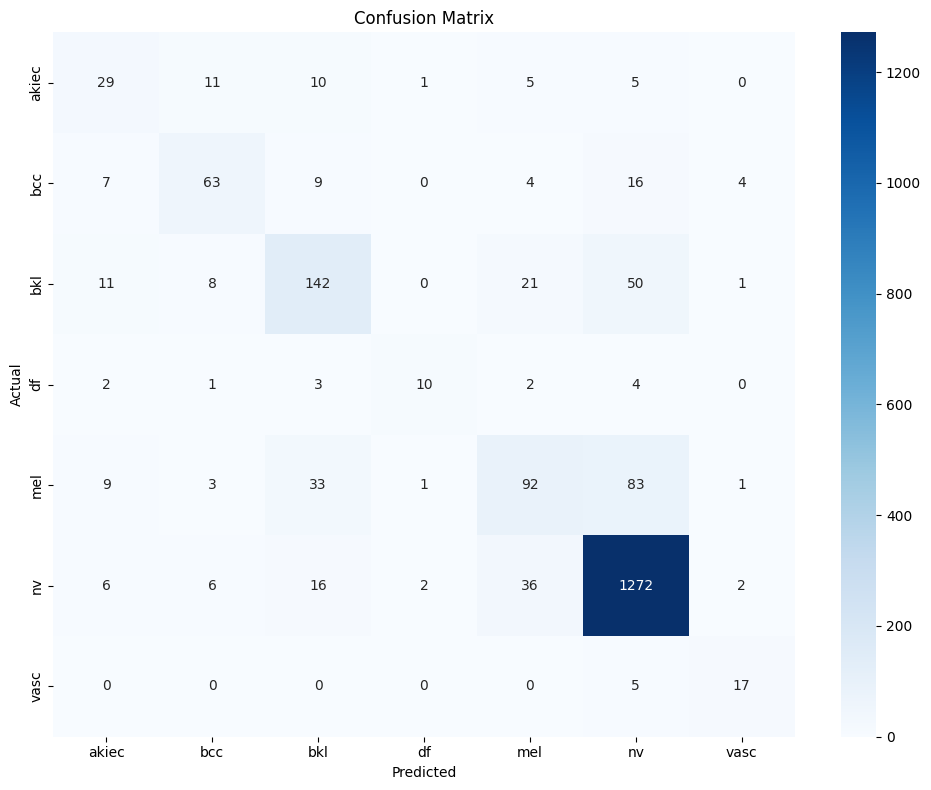

In [23]:

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [24]:
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

       akiec       0.45      0.48      0.46        61
         bcc       0.68      0.61      0.65       103
         bkl       0.67      0.61      0.64       233
          df       0.71      0.45      0.56        22
         mel       0.57      0.41      0.48       222
          nv       0.89      0.95      0.92      1340
        vasc       0.68      0.77      0.72        22

    accuracy                           0.81      2003
   macro avg       0.67      0.61      0.63      2003
weighted avg       0.80      0.81      0.80      2003



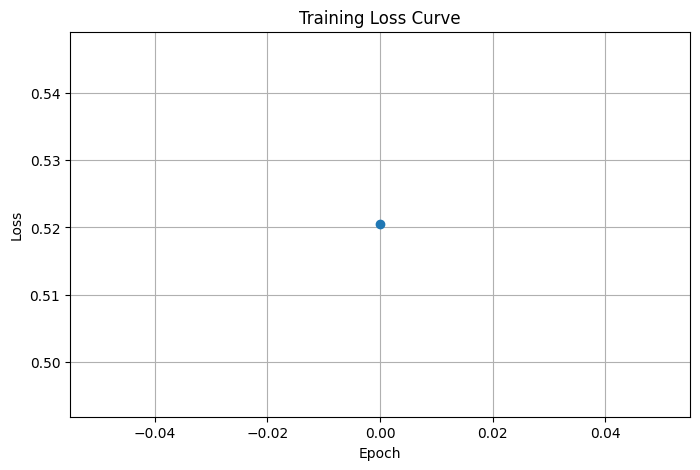

In [25]:
# add this to your training loop first
train_losses = []

# inside epoch loop after avg_loss
train_losses.append(avg_loss)

# after training finishes
plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker='o')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()